In [70]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import joblib

In [71]:
#Datasets
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

In [72]:
scaler = StandardScaler()           #scale data for clustering
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

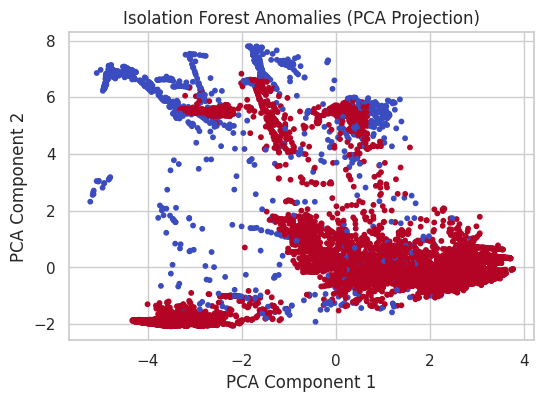

In [73]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_train_scaled)
iso_pred = iso_forest.predict(X_test_scaled)

#PCA visualization for interpretability.
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_2d[:,0], X_2d[:,1], c=iso_pred, cmap='coolwarm', s=10)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Isolation Forest Anomalies (PCA Projection)")
plt.show()

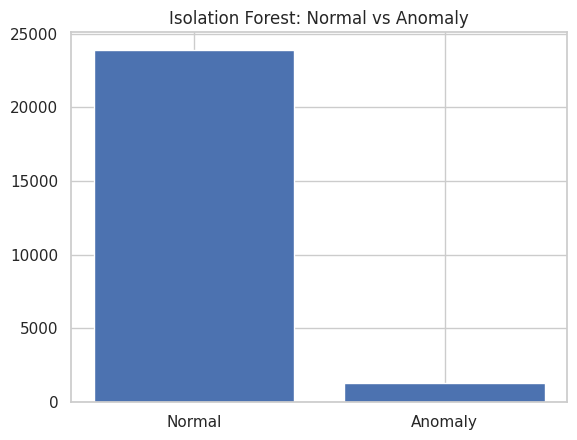

In [74]:
#Isolation forest visualization
iso_labels = np.where(iso_pred == -1, 1, 0)
labels, counts = np.unique(iso_labels, return_counts=True)

plt.bar(['Normal', 'Anomaly'], counts)
plt.title("Isolation Forest: Normal vs Anomaly")
plt.show()
(unique, counts) = np.unique(iso_pred, return_counts=True)

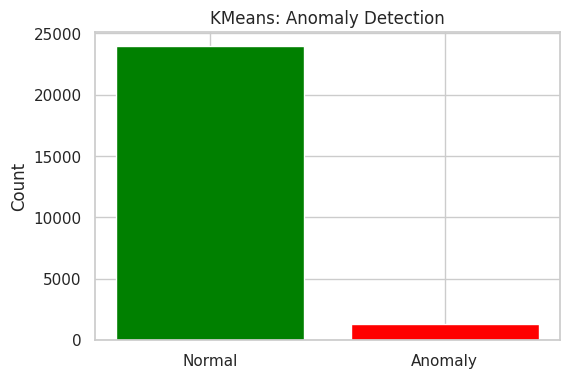

In [75]:
#KMeans Clustering for Anomaly Detection
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_scaled)

kmeans_labels = kmeans.predict(X_test_scaled)

distances = kmeans.transform(X_test_scaled)
min_distances = np.min(distances, axis=1)

threshold = np.percentile(min_distances, 95)
kmeans_anomaly = (min_distances > threshold).astype(int)

(unique, counts) = np.unique(kmeans_anomaly, return_counts=True)
plt.figure(figsize=(6,4))
plt.bar(unique, counts, color=['green','red'])
plt.xticks([0,1], ["Normal", "Anomaly"])
plt.ylabel("Count")
plt.title("KMeans: Anomaly Detection")
plt.show()

--- Isolation Forest Evaluation ---
Accuracy: 0.39464179400674737
Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.99      0.55      9192
           1       0.66      0.37      0.47      2331
           2       0.00      0.00      0.00       199
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00     13469

    accuracy                           0.39     25195
   macro avg       0.21      0.27      0.20     25195
weighted avg       0.20      0.39      0.24     25195



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



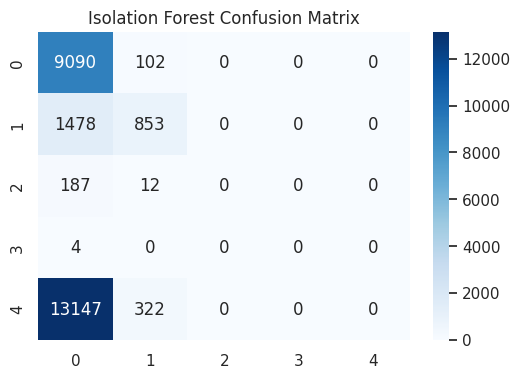

--- KMeans Evaluation ---
Accuracy: 0.37622544155586424
Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.97      0.54      9192
           1       0.45      0.24      0.31      2331
           2       0.00      0.00      0.00       199
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00     13469

    accuracy                           0.38     25195
   macro avg       0.16      0.24      0.17     25195
weighted avg       0.18      0.38      0.23     25195



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



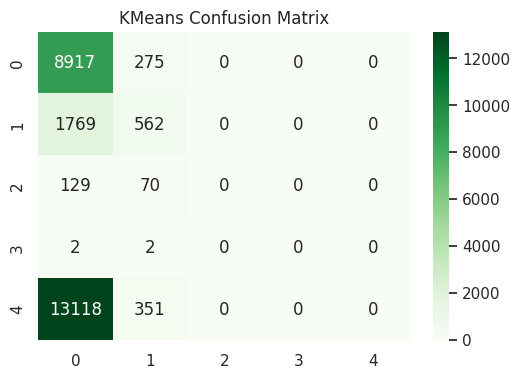

In [76]:
# Evaluation of unsupervised models

def evaluate_anomaly(y_true, y_pred, model_name, cmap_color='Blues'):
    print(f"--- {model_name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_color)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()


# Evaluate Isolation Forest
evaluate_anomaly(y_test, np.where(iso_pred==-1,1,0), "Isolation Forest", cmap_color='Blues')

# Evaluate KMeans
evaluate_anomaly(y_test, kmeans_anomaly, "KMeans", cmap_color='Greens')

In [77]:
#Supervised model Fine-tuning (Random Forest)
#Manual tunning method
best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train.ravel())

print("Random Forest trained with manual hyperparameters")

Random Forest trained with manual hyperparameters


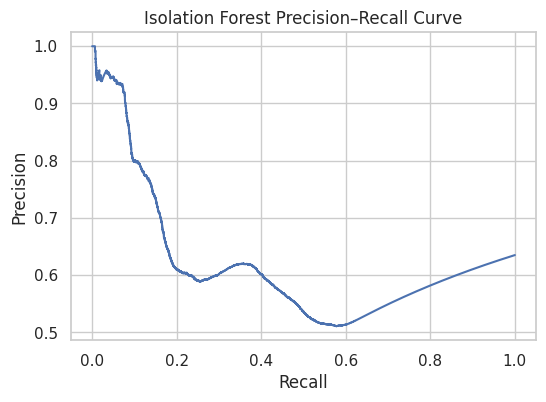

In [80]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

#Get anomaly scores from Isolation Forest
scores = iso_forest.decision_function(X_test_scaled)

# Convert true labels to binary
# 1 = anomaly, 0 = normal
# (Adjust this if your dataset uses a different normal label)
y_true_binary = (y_test != 0).astype(int)

# Invert scores (important!)
# Lower IF score = more anomalous → PR expects higher = positive
scores_inverted = -scores

# Precision–Recall curve
precision, recall, thresholds = precision_recall_curve(
    y_true_binary,
    scores_inverted
)

# Plot
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Isolation Forest Precision–Recall Curve")
plt.show()

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_prob_rf = best_rf.predict_proba(X_test)

# Multi-class ROC using OvR
roc_auc = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class='ovr',
    average='weighted'
)

# ROC curve for a representative class (class 1)
fpr, tpr, thresholds = roc_curve(
    (y_test == 1).astype(int),
    y_prob_rf[:, 1]
)

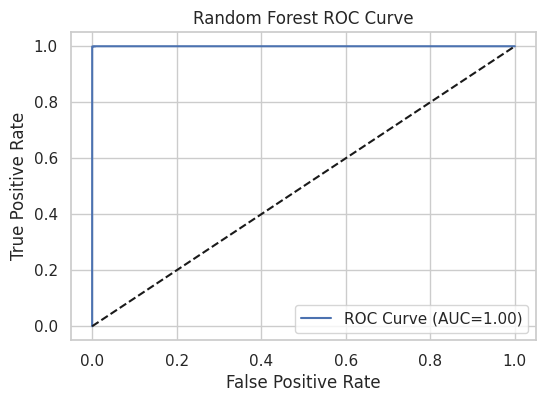

In [82]:
# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()


In [83]:
#Save Fine-tuned Model
import joblib
joblib.dump(best_rf, "rf_model_tuned.npy")
print("Fine-tuned Random Forest saved as rf_model_tuned.npy")

Fine-tuned Random Forest saved as rf_model_tuned.npy
